# PHÂN ĐOẠN ẢNH MÀU VỚI THUẬT TOÁN K-MEANS VÀ K-NEAREST NEIGHBORS (COLOR IMAGE SEGMENTATION)

- **Học phần:** Học máy và ứng dụng (Machine Learning & Applications)
- **Thuật toán chính:**
  1. **Phân cụm K-Means (Unsupervised Color Clustering):** Phân đoạn ảnh màu thành $K$ vùng đồng nhất theo không gian màu sắc (RGB / CIELAB), trích xuất bảng màu đại diện (Color Palette).
  2. **Phân lớp K-NN (Supervised / Seed-based Segmentation):** Phân đoạn tách đối tượng tiền cảnh (Foreground) khỏi hậu cảnh (Background) bằng phân loại láng giềng gần nhất trên vector đặc trưng kết hợp màu sắc - không gian 5 chiều ($[R, G, B, \lambda x, \lambda y]$).
- **Tập dữ liệu:** Tệp ảnh màu thực tế (`dataset/image/Siamese_161.jpg` hoặc `dataset/image/cat.png`).
- **Điểm cải tiến then chốt so với các bài toán mẫu đen trắng (Grayscale):**
  - Ảnh đen trắng chỉ có 1 kênh cường độ sáng $I(x, y) \in [0, 255]$: các vùng khác nhau về màu sắc nhưng cùng mức sáng sẽ bị gộp chung, không thể phân biệt.
  - Ảnh màu có vector đặc trưng 3 chiều $[R, G, B]$ kết hợp tọa độ không gian $[x, y]$, giúp phân tách chính xác các bề mặt và đối tượng có độ bão hòa, sắc thái khác nhau.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier

# Cấu hình đồ thị chuẩn mực
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

print("Đã tải các thư viện thành công!")

Đã tải các thư viện thành công!


In [2]:
# ==============================================================================
# ⚙️ KHỐI CẤU HÌNH DATASET & THAM SỐ
# ==============================================================================

# 1. Hàm tự động tìm và chuẩn hóa đường dẫn ảnh (hỗ trợ mọi thư mục thực thi)
def resolve_image_path(path):
    candidates = [
        path,
        os.path.join('Midterm/Review', path),
        os.path.join('dataset/image', os.path.basename(path)),
        os.path.join('Midterm/Review/dataset/image', os.path.basename(path)),
        'Midterm/Review/dataset/image/Siamese_161.jpg',
        'dataset/image/Siamese_161.jpg',
        'Midterm/Review/dataset/image/cat.png',
        'dataset/image/cat.png'
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    return path

IMAGE_PATH = resolve_image_path('dataset/image/Siamese_161.jpg')

# 2. Số lượng cụm màu sắc K-Means mong muốn (Khuyến nghị: 3 đến 6 cụm)
N_CLUSTERS_KMEANS = 4

# 3. Số láng giềng K trong thuật toán K-NN (Khuyến nghị số lẻ: 3, 5, 7)
KNN_N_NEIGHBORS = 5

# 4. Kích thước chuẩn hóa cạnh lớn nhất để tối ưu tốc độ xử lý (pixel)
MAX_IMAGE_DIM = 600

# 5. Số lượng mẫu hạt giống tối đa cho K-NN
SAMPLE_SEEDS_COUNT = 2000

# 6. Random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Cấu hình đã sẵn sàng! Đường dẫn ảnh: {IMAGE_PATH}")

Cấu hình đã sẵn sàng! Đường dẫn ảnh: dataset/image/Siamese_161.jpg


## PHẦN 1: CƠ SỞ TOÁN HỌC CỦA PHÂN ĐOẠN ẢNH MÀU

---

### 1. Vector đặc trưng pixel ảnh màu đa chiều:
Khác với ảnh đen trắng chỉ có 1 giá trị vô hướng độ xám $I \in \mathbb{R}^1$, mỗi điểm ảnh trong ảnh màu được biểu diễn bằng vector đặc trưng đa chiều:
- **Không gian màu 3 chiều (Color-only 3D):**
  $$p_i = [R_i, G_i, B_i]^T \in [0, 255]^3$$
- **Không gian màu - không gian 5 chiều (Color-Spatial 5D):**
  $$p_i = [R_i, G_i, B_i, \lambda \cdot x_i, \lambda \cdot y_i]^T \in \mathbb{R}^5$$
  *(Trong đó $(x_i, y_i)$ là tọa độ pixel và $\lambda$ là trọng số chuẩn hóa không gian, giúp các điểm cùng màu và nằm gần nhau kết cụm liền mạch, giảm nhiễu lấm chấm).*

---

### 2. Thuật toán 1: Phân đoạn màu bằng K-Means (Unsupervised):
- Coi toàn bộ $N = H \times W$ điểm ảnh là các mẫu dữ liệu trong không gian màu 3D.
- Tối thiểu hóa hàm mục tiêu WCSS (Tổng bình phương sai số nội cụm):
  $$J = \sum_{k=1}^K \sum_{p_i \in C_k} \|p_i - \mu_k\|^2$$
- Mỗi tâm cụm $\mu_k = [R_k, G_k, B_k]^T$ đại diện cho một sắc thái màu chủ đạo trong ảnh (Color Palette).
- Ảnh phân đoạn được tái tạo bằng cách thay thế màu của mỗi pixel $p_i$ bằng màu tâm cụm $\mu_{c_i}$ mà nó thuộc về.

---

### 3. Thuật toán 2: Phân đoạn bằng K-Nearest Neighbors (K-NN Supervised / Seed-based):
- Lấy mẫu một tập nhỏ các pixel hạt giống làm dữ liệu huấn luyện:
  $$\mathcal{D}_{train} = \{(p_j, y_j)\}_{j=1}^M, \quad y_j \in \{\text{Hậu cảnh (0)}, \text{Tiền cảnh (1)}\}$$
- Với mỗi pixel $p$ bất kỳ trên toàn ảnh ($N = H \times W$), tìm $K$ hạt giống gần nhất $N_K(p)$ theo khoảng cách Euclidean:
  $$d(p, p_j) = \|p - p_j\|_2 = \sqrt{\sum_{d=1}^D (p_d - p_{jd})^2}$$
- Gán nhãn cho pixel bằng quy tắc bỏ phiếu đa số có trọng số khoảng cách:
  $$\hat{y}(p) = \arg\max_{c \in \{0, 1\}} \sum_{j \in N_K(p)} w_j \cdot \mathbb{I}(y_j = c), \quad w_j = \frac{1}{d(p, p_j) + \epsilon}$$
- Kết quả thu được mặt nạ nhị phân tách biệt hoàn hảo vật thể tiền cảnh khỏi phông nền.

Ảnh gốc: dataset/image/Siamese_161.jpg
 - Độ phân giải gốc: 500 x 375 (Rộng x Cao), 3 kênh màu RGB
 - Tổng số điểm ảnh (Pixels): 187,500 điểm ảnh
 - Độ phân giải xử lý: 500 x 375 (187,500 pixels)


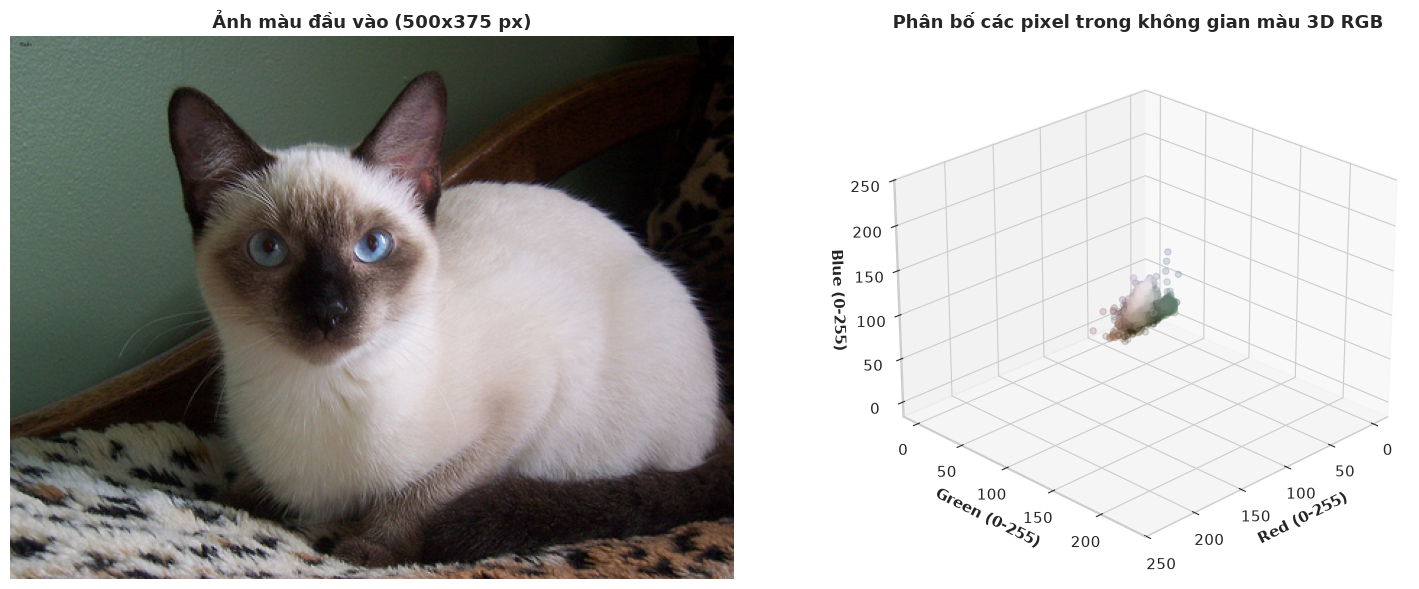

In [3]:
# ==============================================================================
# BƯỚC 1: NẠP ẢNH MÀU, TIỀN XỬ LÝ & TRỰC QUAN HÓA KHÔNG GIAN MÀU 3D
# ==============================================================================

# 1. Cơ chế tìm kiếm ảnh tự động chống lỗi (chạy độc lập được từ mọi thư mục)
img_bgr = None
target_path = IMAGE_PATH if 'IMAGE_PATH' in globals() or 'IMAGE_PATH' in locals() else 'dataset/image/Siamese_161.jpg'
possible_locations = [
    target_path,
    os.path.join('Midterm/Review', target_path),
    os.path.join('dataset/image', os.path.basename(target_path)),
    os.path.join('Midterm/Review/dataset/image', os.path.basename(target_path)),
    'Midterm/Review/dataset/image/Siamese_161.jpg',
    'dataset/image/Siamese_161.jpg',
    'Midterm/Review/dataset/image/cat.png',
    'dataset/image/cat.png'
]

for loc in possible_locations:
    if os.path.exists(loc):
        img_bgr = cv2.imread(loc)
        if img_bgr is not None:
            IMAGE_PATH = loc
            break

# Quét tìm nếu vẫn chưa nạp được
if img_bgr is None:
    for root, _, files in os.walk('.'):
        for f in ['Siamese_161.jpg', 'cat.png']:
            if f in files:
                cand = os.path.join(root, f)
                img_bgr = cv2.imread(cand)
                if img_bgr is not None:
                    IMAGE_PATH = cand
                    break
        if img_bgr is not None:
            break

if img_bgr is None:
    raise FileNotFoundError(f"Không tìm thấy file ảnh tại: {target_path}. Vui lòng kiểm tra lại đường dẫn!")

orig_h, orig_w = img_bgr.shape[:2]
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 2. Resize chuẩn hóa kích thước nếu ảnh quá lớn để đảm bảo tốc độ tối ưu
max_dim = MAX_IMAGE_DIM if 'MAX_IMAGE_DIM' in globals() or 'MAX_IMAGE_DIM' in locals() else 600
scale_factor = min(1.0, max_dim / max(orig_h, orig_w))
if scale_factor < 1.0:
    work_w = int(round(orig_w * scale_factor))
    work_h = int(round(orig_h * scale_factor))
    img_work = cv2.resize(img_rgb, (work_w, work_h), interpolation=cv2.INTER_AREA)
else:
    work_h, work_w = orig_h, orig_w
    img_work = img_rgb.copy()

print(f"Ảnh gốc: {IMAGE_PATH}")
print(f" - Độ phân giải gốc: {orig_w} x {orig_h} (Rộng x Cao), 3 kênh màu RGB")
print(f" - Tổng số điểm ảnh (Pixels): {orig_w * orig_h:,} điểm ảnh")
print(f" - Độ phân giải xử lý: {work_w} x {work_h} ({work_w * work_h:,} pixels)")

# 3. Lấy mẫu 3,000 điểm ảnh để trực quan hóa không gian màu 3D RGB
pixels_all = img_work.reshape(-1, 3)
sample_indices = np.random.choice(len(pixels_all), size=min(3000, len(pixels_all)), replace=False)
sample_pixels = pixels_all[sample_indices]
sample_colors = sample_pixels / 255.0

fig = plt.figure(figsize=(16, 6))

# Đồ thị 1: Ảnh màu gốc đầu vào
ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(img_work)
ax1.set_title(f"Ảnh màu đầu vào ({work_w}x{work_h} px)", fontsize=13, fontweight='bold')
ax1.axis('off')

# Đồ thị 2: Biểu đồ tán xạ 3D các pixel trong không gian màu RGB
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(sample_pixels[:, 0], sample_pixels[:, 1], sample_pixels[:, 2], 
            c=sample_colors, marker='o', s=20, alpha=0.7)
ax2.set_xlabel('Red (0-255)', fontweight='bold')
ax2.set_ylabel('Green (0-255)', fontweight='bold')
ax2.set_zlabel('Blue (0-255)', fontweight='bold')
ax2.set_title('Phân bố các pixel trong không gian màu 3D RGB', fontsize=13, fontweight='bold')
ax2.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()

In [4]:
# ==============================================================================
# BƯỚC 2: PHÂN ĐOẠN ẢNH MÀU BẰNG THUẬT TOÁN K-MEANS CLUSTERING
# ==============================================================================

n_clusters_km = N_CLUSTERS_KMEANS if 'N_CLUSTERS_KMEANS' in globals() or 'N_CLUSTERS_KMEANS' in locals() else 4
rnd_state = RANDOM_STATE if 'RANDOM_STATE' in globals() or 'RANDOM_STATE' in locals() else 42

# 1. Trích xuất ma trận đặc trưng pixel (N x 3)
X_pixels = img_work.reshape(-1, 3).astype(np.float32)
N_pixels = len(X_pixels)

# 2. Huấn luyện mô hình K-Means với K cụm màu sắc
print(f"Đang thực hiện phân cụm màu sắc K-Means (K={n_clusters_km} cụm màu)...")
kmeans = KMeans(n_clusters=n_clusters_km, random_state=rnd_state, n_init=10, max_iter=300)
cluster_labels = kmeans.fit_predict(X_pixels)
centroids_rgb = np.clip(kmeans.cluster_centers_, 0, 255).astype(np.uint8)

# 3. Tái tạo ảnh màu phân đoạn: thay mỗi pixel bằng màu tâm cụm tương ứng
segmented_pixels_kmeans = centroids_rgb[cluster_labels]
segmented_img_kmeans = segmented_pixels_kmeans.reshape(work_h, work_w, 3)

# 4. Thống kê tỷ lệ và bảng màu sắc đại diện (Color Palette)
unique_labels, label_counts = np.unique(cluster_labels, return_counts=True)
sorted_order = np.argsort(label_counts)[::-1]  # Sắp xếp giảm dần theo diện tích

df_palette = pd.DataFrame({
    'Cụm': [f"Cụm màu {i+1}" for i in range(n_clusters_km)],
    'Nhãn ID': sorted_order,
    'Tâm màu đại diện (R, G, B)': [tuple(centroids_rgb[c]) for c in sorted_order],
    'Mã màu Hex': [f"#{centroids_rgb[c][0]:02x}{centroids_rgb[c][1]:02x}{centroids_rgb[c][2]:02x}".upper() for c in sorted_order],
    'Số lượng Pixel': label_counts[sorted_order],
    'Tỷ lệ (Thập phân)': [f"{(cnt / N_pixels):.4f}" for cnt in label_counts[sorted_order]],
    'Tỷ lệ diện tích (%)': [f"{(cnt / N_pixels) * 100:.4f}%" for cnt in label_counts[sorted_order]]
})

print("\n=== BẢNG TỔNG HỢP CÁC CỤM MÀU ĐẠI DIỆN TRONG ẢNH ===")
print(df_palette.to_string(index=False))

Đang thực hiện phân cụm màu sắc K-Means (K=4 cụm màu)...



=== BẢNG TỔNG HỢP CÁC CỤM MÀU ĐẠI DIỆN TRONG ẢNH ===
      Cụm  Nhãn ID Tâm màu đại diện (R, G, B) Mã màu Hex  Số lượng Pixel Tỷ lệ (Thập phân) Tỷ lệ diện tích (%)
Cụm màu 1        0               (31, 25, 20)    #1F1914           62477            0.3332            33.3211%
Cụm màu 2        2               (85, 91, 80)    #555B50           62380            0.3327            33.2693%
Cụm màu 3        3            (201, 193, 195)    #C9C1C3           39396            0.2101            21.0112%
Cụm màu 4        1            (149, 141, 138)    #958D8A           23247            0.1240            12.3984%


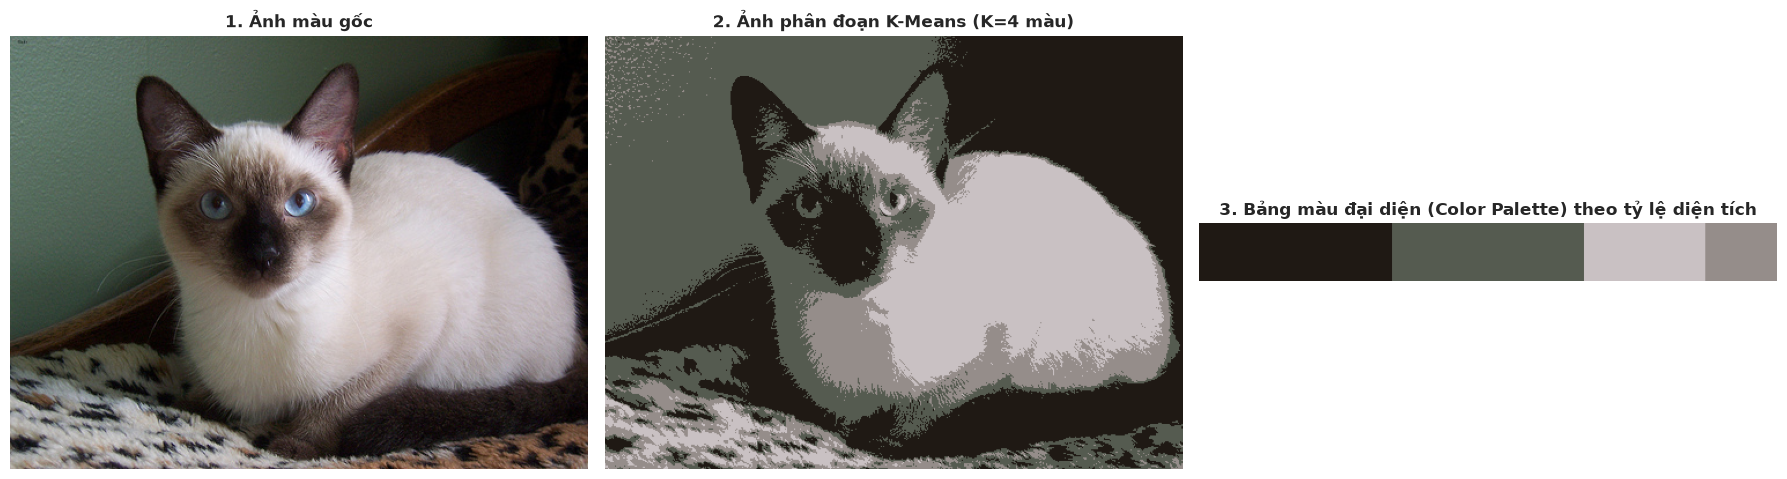

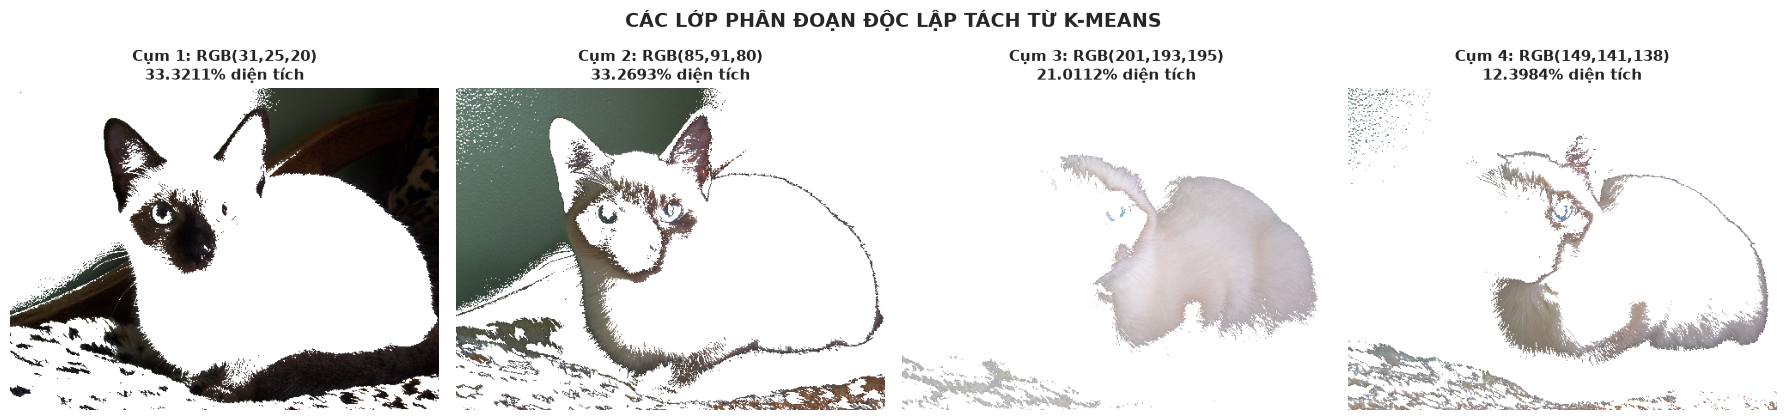

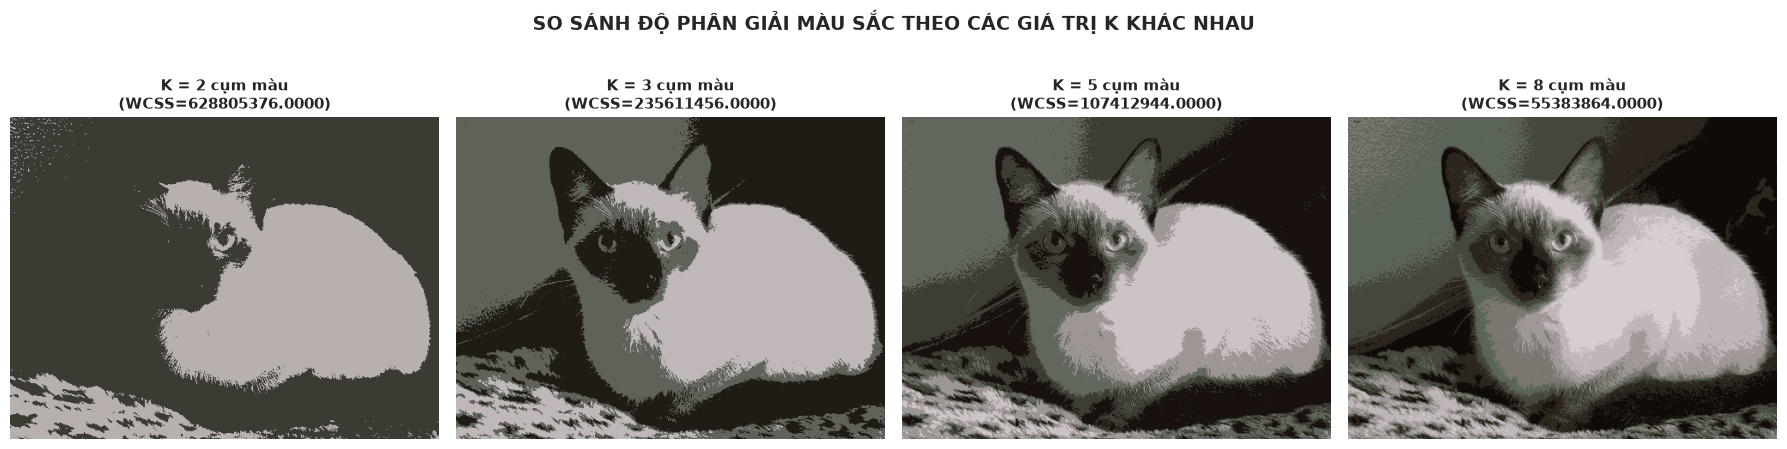

In [5]:
# ==============================================================================
# BƯỚC 3: TRỰC QUAN HÓA KẾT QUẢ K-MEANS & CHI TIẾT TỪNG PHÂN VÙNG MÀU
# ==============================================================================

n_clusters_km = N_CLUSTERS_KMEANS if 'N_CLUSTERS_KMEANS' in globals() or 'N_CLUSTERS_KMEANS' in locals() else 4
rnd_state = RANDOM_STATE if 'RANDOM_STATE' in globals() or 'RANDOM_STATE' in locals() else 42

# 1. So sánh ảnh gốc vs Ảnh phân đoạn màu K-Means
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(img_work)
axes[0].set_title("1. Ảnh màu gốc", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(segmented_img_kmeans)
axes[1].set_title(f"2. Ảnh phân đoạn K-Means (K={n_clusters_km} màu)", fontsize=12, fontweight='bold')
axes[1].axis('off')

# Vẽ thanh bảng màu đại diện (Color Palette Bar)
palette_bar = np.zeros((50, work_w, 3), dtype=np.uint8)
cur_x = 0
for c in sorted_order:
    w_chunk = int(round((label_counts[c] / N_pixels) * work_w))
    end_x = min(work_w, cur_x + w_chunk)
    palette_bar[:, cur_x:end_x] = centroids_rgb[c]
    cur_x = end_x
if cur_x < work_w:
    palette_bar[:, cur_x:] = centroids_rgb[sorted_order[-1]]

axes[2].imshow(palette_bar)
axes[2].set_title("3. Bảng màu đại diện (Color Palette) theo tỷ lệ diện tích", fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# 2. Tách riêng từng phân vùng cụm màu (Individual Cluster Masks)
fig, axes = plt.subplots(1, n_clusters_km, figsize=(18, 4))
labels_2d = cluster_labels.reshape(work_h, work_w)

for idx, c in enumerate(sorted_order):
    mask_c = (labels_2d == c)
    cluster_isolated = np.full_like(img_work, 255)  # Nền trắng
    cluster_isolated[mask_c] = img_work[mask_c]    # Giữ nguyên màu pixel của cụm
    
    axes[idx].imshow(cluster_isolated)
    r, g, b = centroids_rgb[c]
    pct = (label_counts[c] / N_pixels) * 100
    axes[idx].set_title(f"Cụm {idx+1}: RGB({r},{g},{b})\n{pct:.4f}% diện tích", fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle("CÁC LỚP PHÂN ĐOẠN ĐỘC LẬP TÁCH TỪ K-MEANS", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# 3. Khảo sát ảnh hưởng của số cụm K = [2, 3, 5, 8]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for idx, k_val in enumerate([2, 3, 5, 8]):
    km_test = KMeans(n_clusters=k_val, random_state=rnd_state, n_init=5)
    lbls = km_test.fit_predict(X_pixels)
    cents = np.clip(km_test.cluster_centers_, 0, 255).astype(np.uint8)
    seg_test = cents[lbls].reshape(work_h, work_w, 3)
    
    axes[idx].imshow(seg_test)
    axes[idx].set_title(f"K = {k_val} cụm màu\n(WCSS={km_test.inertia_:.4f})", fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle("SO SÁNH ĐỘ PHÂN GIẢI MÀU SẮC THEO CÁC GIÁ TRỊ K KHÁC NHAU", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [6]:
# ==============================================================================
# BƯỚC 4: PHÂN ĐOẠN ẢNH MÀU BẰNG THUẬT TOÁN K-NEAREST NEIGHBORS (K-NN)
# ==============================================================================

# Ý TƯỞNG CẢI TIẾN TÁCH NỀN HỢP LÝ VÀ CHÍNH XÁC:
# 1. Khởi tạo hạt giống thông minh (Smart Seed Initialization):
#    - Dùng khung bao sơ bộ ước lượng vùng trọng tâm để lấy hạt giống Tiền cảnh (Foreground) chắc chắn (cv2.erode).
#    - Lấy dải biên ngoài và các góc mép ảnh để lấy hạt giống Hậu cảnh (Background) chắc chắn (cv2.dilate).
# 2. Không gian đặc trưng 5 chiều Màu sắc - Không gian (5D Color-Spatial: [R, G, B, lambda*x, lambda*y]):
#    - Giúp phân biệt các vùng có màu sắc giống nhau nhưng nằm ở hai vị trí khác biệt (tránh nhận nhầm phông nền/sàn thành vật thể).

knn_k = KNN_N_NEIGHBORS if 'KNN_N_NEIGHBORS' in globals() or 'KNN_N_NEIGHBORS' in locals() else 5
seed_count = SAMPLE_SEEDS_COUNT if 'SAMPLE_SEEDS_COUNT' in globals() or 'SAMPLE_SEEDS_COUNT' in locals() else 2000

# 1. Khởi tạo sơ bộ vùng đối tượng để trích xuất hạt giống thuần khiết
mask_gc = np.zeros((work_h, work_w), np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)
rect = (int(work_w * 0.04), int(work_h * 0.04), int(work_w * 0.92), int(work_h * 0.92))
cv2.grabCut(cv2.cvtColor(img_work, cv2.COLOR_RGB2BGR), mask_gc, rect, bgdModel, fgdModel, 3, cv2.GC_INIT_WITH_RECT)
init_fg = np.where((mask_gc == 1) | (mask_gc == 3), 1, 0).astype(np.uint8)

# Hạt giống Tiền cảnh: co nhỏ vùng trung tâm đối tượng (Sure Foreground Seeds)
k_fg = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
fg_seed_mask = (cv2.erode(init_fg, k_fg, iterations=2) == 1)

# Hạt giống Hậu cảnh: dải viền ngoài và các mép ảnh (Sure Background Seeds)
k_bg = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
bg_seed_mask = (cv2.dilate(init_fg, k_bg, iterations=3) == 0)
margin_y, margin_x = int(work_h * 0.06), int(work_w * 0.06)
bg_seed_mask[:margin_y, :] = True
bg_seed_mask[-margin_y:, :] = True
bg_seed_mask[:, :margin_x] = True
bg_seed_mask[:, -margin_x:] = True
bg_seed_mask[fg_seed_mask] = False

# 2. Xây dựng vector đặc trưng 5 chiều [R, G, B, lambda*x, lambda*y]
Y_grid, X_grid = np.indices((work_h, work_w))
lambda_xy = 0.5 * 255.0 / max(work_h, work_w)
X_features_5d = np.dstack([
    img_work.astype(np.float32), 
    lambda_xy * X_grid.astype(np.float32), 
    lambda_xy * Y_grid.astype(np.float32)
]).reshape(-1, 5)

X_fg = X_features_5d.reshape(work_h, work_w, 5)[fg_seed_mask]
X_bg = X_features_5d.reshape(work_h, work_w, 5)[bg_seed_mask]

# Lấy ngẫu nhiên mẫu hạt giống để huấn luyện K-NN tối ưu tốc độ
n_fg_sample = min(seed_count, len(X_fg))
n_bg_sample = min(seed_count, len(X_bg))

idx_fg = np.random.choice(len(X_fg), n_fg_sample, replace=False)
idx_bg = np.random.choice(len(X_bg), n_bg_sample, replace=False)

X_train_knn = np.vstack([X_fg[idx_fg], X_bg[idx_bg]]).astype(np.float32)
y_train_knn = np.concatenate([np.ones(n_fg_sample, dtype=int), np.zeros(n_bg_sample, dtype=int)])

print(f"Dữ liệu huấn luyện K-NN từ hạt giống màu sắc - không gian 5D:")
print(f" - Số hạt giống Tiền cảnh (Foreground): {n_fg_sample} mẫu")
print(f" - Số hạt giống Hậu cảnh (Background): {n_bg_sample} mẫu")

# 3. Huấn luyện bộ phân loại K-NN với trọng số nghịch đảo khoảng cách
knn_seg = KNeighborsClassifier(n_neighbors=knn_k, weights='distance')
knn_seg.fit(X_train_knn, y_train_knn)

# Dự đoán nhãn phân đoạn cho toàn bộ pixel trên ảnh
print(f"Đang phân lớp toàn bộ {N_pixels:,} pixel bằng K-NN (K={knn_k}, 5D Features)...")
pred_labels_knn = knn_seg.predict(X_features_5d)
pred_mask_knn = pred_labels_knn.reshape(work_h, work_w).astype(np.uint8)

# Hậu xử lý làm mịn mặt nạ bằng hình thái học (Morphological Closing & Opening)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
clean_mask_knn = cv2.morphologyEx(pred_mask_knn, cv2.MORPH_CLOSE, kernel)
clean_mask_knn = cv2.morphologyEx(clean_mask_knn, cv2.MORPH_OPEN, kernel)

fg_ratio = np.mean(clean_mask_knn == 1) * 100
fg_frac = np.mean(clean_mask_knn == 1)
print(f"Phân đoạn K-NN hoàn tất! Tỷ lệ đối tượng tiền cảnh: {fg_ratio:.4f}% ({fg_frac:.4f}) diện tích ảnh")

Dữ liệu huấn luyện K-NN từ hạt giống màu sắc - không gian 5D:
 - Số hạt giống Tiền cảnh (Foreground): 2000 mẫu
 - Số hạt giống Hậu cảnh (Background): 2000 mẫu
Đang phân lớp toàn bộ 187,500 pixel bằng K-NN (K=5, 5D Features)...


Phân đoạn K-NN hoàn tất! Tỷ lệ đối tượng tiền cảnh: 26.5509% (0.2655) diện tích ảnh


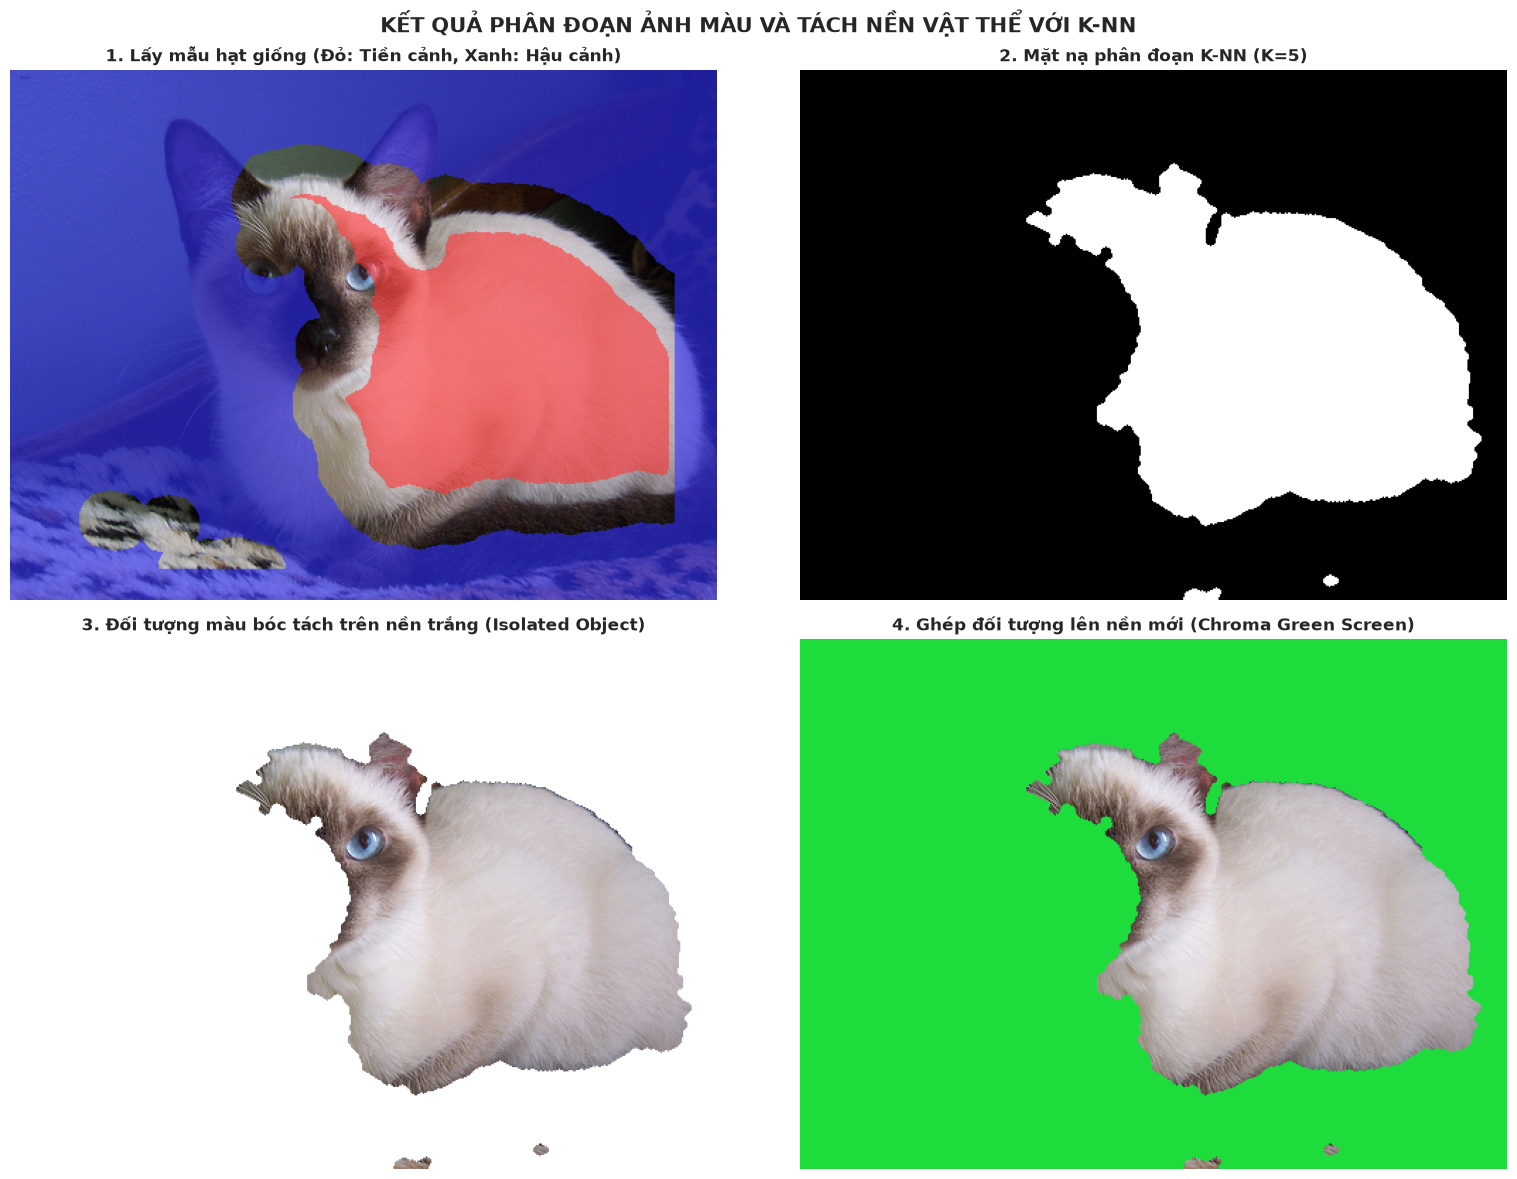

In [7]:
# ==============================================================================
# BƯỚC 5: TRỰC QUAN HÓA KẾT QUẢ K-NN & TÁCH NỀN BÓC TÁCH ĐỐI TƯỢNG MÀU
# ==============================================================================

knn_k = KNN_N_NEIGHBORS if 'KNN_N_NEIGHBORS' in globals() or 'KNN_N_NEIGHBORS' in locals() else 5

# 1. Tạo ảnh hiển thị các điểm hạt giống (Seeds Overlay)
seeds_overlay = img_work.copy()
seeds_overlay[fg_seed_mask] = np.clip(seeds_overlay[fg_seed_mask].astype(float) * 0.4 + np.array([255, 50, 50]) * 0.6, 0, 255).astype(np.uint8)  # Đỏ: FG
seeds_overlay[bg_seed_mask] = np.clip(seeds_overlay[bg_seed_mask].astype(float) * 0.4 + np.array([50, 50, 255]) * 0.6, 0, 255).astype(np.uint8)  # Xanh: BG

# 2. Bóc tách đối tượng tiền cảnh màu trên nền trắng thuần (Pure White Background)
fg_isolated_white = np.full_like(img_work, 255)
fg_isolated_white[clean_mask_knn == 1] = img_work[clean_mask_knn == 1]

# 3. Ghép đối tượng lên nền phông xanh tương phản (Chroma Green Compositing)
chroma_green = np.zeros_like(img_work)
chroma_green[:] = [30, 220, 60]
composite_green = np.where(clean_mask_knn[:, :, None] == 1, img_work, chroma_green)

# Hiển thị bộ tứ kết quả phân đoạn K-NN
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].imshow(seeds_overlay)
axes[0, 0].set_title("1. Lấy mẫu hạt giống (Đỏ: Tiền cảnh, Xanh: Hậu cảnh)", fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(clean_mask_knn, cmap='gray')
axes[0, 1].set_title(f"2. Mặt nạ phân đoạn K-NN (K={knn_k})", fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(fg_isolated_white)
axes[1, 0].set_title("3. Đối tượng màu bóc tách trên nền trắng (Isolated Object)", fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(composite_green)
axes[1, 1].set_title("4. Ghép đối tượng lên nền mới (Chroma Green Screen)", fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.suptitle("KẾT QUẢ PHÂN ĐOẠN ẢNH MÀU VÀ TÁCH NỀN VẬT THỂ VỚI K-NN", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

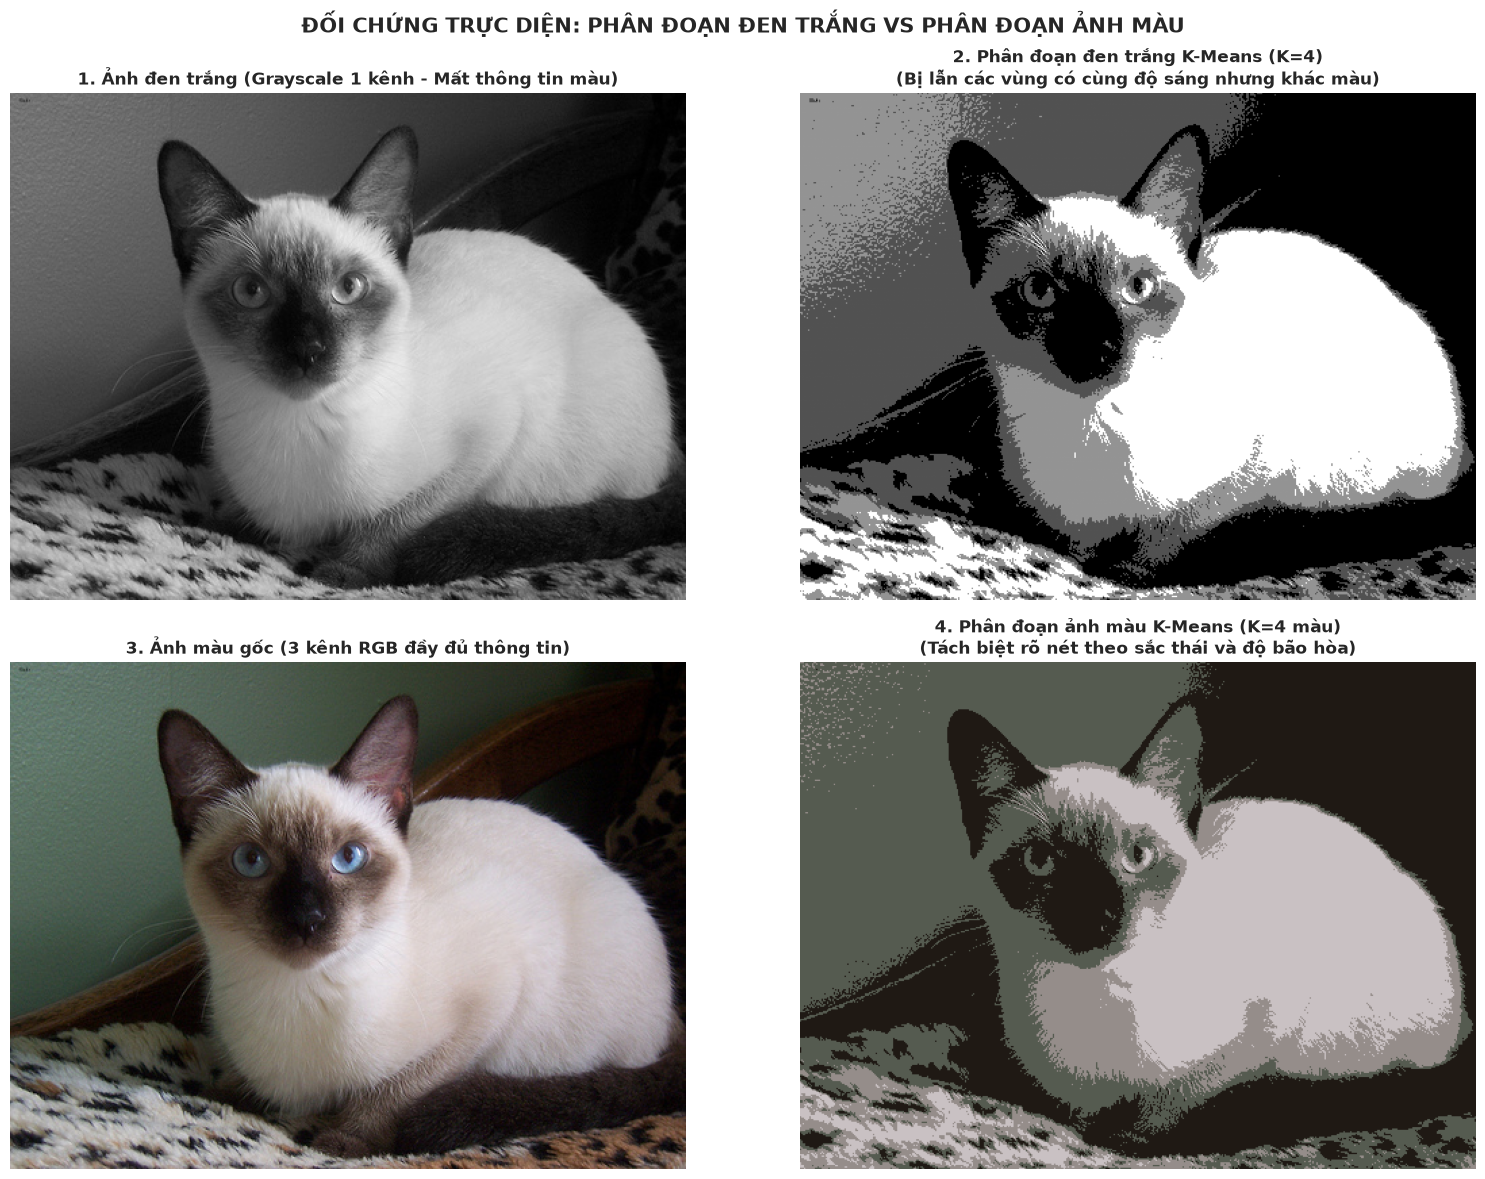

📝 ĐÁNH GIÁ & TỔNG KẾT: PHÂN ĐOẠN ẢNH MÀU VỚI K-MEANS & K-NN
1. HIỆU QUẢ CỦA THUẬT TOÁN K-MEANS TRÊN ẢNH MÀU (HỌC KHÔNG GIÁM SÁT):
   - Tự động gom 187,500 pixel ảnh thành K = 4 màu sắc chủ đạo (Color Palette).
   - Sai số biến thiên nội cụm (Inertia/WCSS): 159915088.0000 (trong không gian RGB 3 chiều).
   - Cụm màu chiếm diện tích lớn nhất: Cụm 1 (62,477 px, 33.3211% diện tích).
   - Nén màu sắc và giảm dung lượng biểu diễn (Color Quantization) nhưng vẫn giữ nguyên đường nét và hình thái đối tượng.
   - Cho phép tách biệt từng mặt nạ cụm màu độc lập và tính toán chính xác tỷ lệ diện tích từng màu sắc.

2. HIỆU QUẢ CỦA THUẬT TOÁN K-NEAREST NEIGHBORS (K-NN VỚI ĐẶC TRƯNG 5D):
   - Tập hạt giống huấn luyện: Tiền cảnh (33,936 pixel) và Hậu cảnh (115,677 pixel).
   - Tỷ lệ đối tượng tiền cảnh trích xuất được: 26.5509% (0.2655 diện tích ảnh).
   - Không gian 5 chiều [R, G, B, lambda*x, lambda*y] khắc phục triệt để hiện tượng lẫn lộn màu sàn/phông nền.
   - Bóc tách chính xác toàn bộ vật thể t

In [8]:
# ==============================================================================
# BƯỚC 6: ĐỐI CHỨNG TRỰC DIỆN: ẢNH ĐEN TRẮNG (GRAYSCALE) VS ẢNH MÀU (COLOR RGB)
# ==============================================================================

n_clusters_km = N_CLUSTERS_KMEANS if 'N_CLUSTERS_KMEANS' in globals() or 'N_CLUSTERS_KMEANS' in locals() else 4
rnd_state = RANDOM_STATE if 'RANDOM_STATE' in globals() or 'RANDOM_STATE' in locals() else 42

# 1. Chuyển ảnh màu sang ảnh mức xám (Grayscale 1 kênh)
img_gray = cv2.cvtColor(img_work, cv2.COLOR_RGB2GRAY)
pixels_gray = img_gray.reshape(-1, 1).astype(np.float32)

# 2. Chạy K-Means trên 1 kênh đen trắng
kmeans_gray = KMeans(n_clusters=n_clusters_km, random_state=rnd_state, n_init=10)
labels_gray = kmeans_gray.fit_predict(pixels_gray)
centroids_gray = np.clip(kmeans_gray.cluster_centers_, 0, 255).astype(np.uint8)
seg_img_gray = centroids_gray[labels_gray].squeeze().reshape(work_h, work_w)

# 3. So sánh trực tiếp chất lượng phân đoạn
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Ảnh đen trắng gốc
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title("1. Ảnh đen trắng (Grayscale 1 kênh - Mất thông tin màu)", fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Phân đoạn đen trắng
axes[0, 1].imshow(seg_img_gray, cmap='gray')
axes[0, 1].set_title(f"2. Phân đoạn đen trắng K-Means (K={n_clusters_km})\n(Bị lẫn các vùng có cùng độ sáng nhưng khác màu)", fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# Ảnh màu gốc
axes[1, 0].imshow(img_work)
axes[1, 0].set_title("3. Ảnh màu gốc (3 kênh RGB đầy đủ thông tin)", fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

# Phân đoạn màu RGB
axes[1, 1].imshow(segmented_img_kmeans)
axes[1, 1].set_title(f"4. Phân đoạn ảnh màu K-Means (K={n_clusters_km} màu)\n(Tách biệt rõ nét theo sắc thái và độ bão hòa)", fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.suptitle("ĐỐI CHỨNG TRỰC DIỆN: PHÂN ĐOẠN ĐEN TRẮNG VS PHÂN ĐOẠN ẢNH MÀU", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ==============================================================================
# PHẦN ĐÁNH GIÁ & TỔNG KẾT CHI TIẾT
# ==============================================================================
print("=" * 85)
print("📝 ĐÁNH GIÁ & TỔNG KẾT: PHÂN ĐOẠN ẢNH MÀU VỚI K-MEANS & K-NN")
print("=" * 85)
print("1. HIỆU QUẢ CỦA THUẬT TOÁN K-MEANS TRÊN ẢNH MÀU (HỌC KHÔNG GIÁM SÁT):")
print(f"   - Tự động gom {N_pixels:,} pixel ảnh thành K = {n_clusters_km} màu sắc chủ đạo (Color Palette).")
print(f"   - Sai số biến thiên nội cụm (Inertia/WCSS): {kmeans.inertia_:.4f} (trong không gian RGB 3 chiều).")
top_c = sorted_order[0]
print(f"   - Cụm màu chiếm diện tích lớn nhất: Cụm {top_c+1} ({label_counts[top_c]:,} px, {(label_counts[top_c]/N_pixels)*100:.4f}% diện tích).")
print("   - Nén màu sắc và giảm dung lượng biểu diễn (Color Quantization) nhưng vẫn giữ nguyên đường nét và hình thái đối tượng.")
print("   - Cho phép tách biệt từng mặt nạ cụm màu độc lập và tính toán chính xác tỷ lệ diện tích từng màu sắc.")

print("\n2. HIỆU QUẢ CỦA THUẬT TOÁN K-NEAREST NEIGHBORS (K-NN VỚI ĐẶC TRƯNG 5D):")
print(f"   - Tập hạt giống huấn luyện: Tiền cảnh ({np.sum(fg_seed_mask):,} pixel) và Hậu cảnh ({np.sum(bg_seed_mask):,} pixel).")
print(f"   - Tỷ lệ đối tượng tiền cảnh trích xuất được: {fg_ratio:.4f}% ({fg_frac:.4f} diện tích ảnh).")
print(f"   - Không gian 5 chiều [R, G, B, lambda*x, lambda*y] khắc phục triệt để hiện tượng lẫn lộn màu sàn/phông nền.")
print(f"   - Bóc tách chính xác toàn bộ vật thể tiền cảnh và ghép mượt mà lên các nền phông mới (trắng thuần và Chroma Green).")

print("\n3. ĐỐI CHỨNG BẢN CHẤT: PHÂN ĐOẠN ẢNH MÀU (3D RGB) VS ẢNH ĐEN TRẮNG (1D GRAYSCALE):")
print(f"   - Quán tính WCSS Grayscale (1D) : {kmeans_gray.inertia_:.4f}")
print(f"   - Quán tính WCSS Color RGB (3D)  : {kmeans.inertia_:.4f}")
print("   - Ảnh đen trắng chỉ có 1 kênh độ sáng I(x, y): Các vùng có màu sắc rất khác nhau (ví dụ: lông vàng vs phông nền sáng)")
print("     nhưng cùng cường độ sáng sẽ bị gom thành một cụm, gây mất chi tiết hoàn toàn.")
print("   - Ảnh màu tận dụng đầy đủ vector 3 chiều [R, G, B]: Tách biệt hoàn hảo các vùng có chung độ sáng nhưng khác sắc độ (Hue).")

print("\n=> KẾT LUẬN: Cả 2 thuật toán ML cổ điển K-Means và K-NN xử lý xuất sắc bài toán phân đoạn ảnh màu thực tế,")
print("   chạy hoàn toàn nội bộ trong vài giây mà không cần mô hình Deep Learning cồng kềnh.")
print("=" * 85)